1. CÀI ĐẶT THƯ VIỆN

In [ ]:
pip install opencv-python # type: ignore

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


2. VIẾT CHƯƠNG TRÌNH PHÂN VÙNG ẢNH

2.1. Phân vùng theo histogram

2.1.1. Phương pháp Otsu

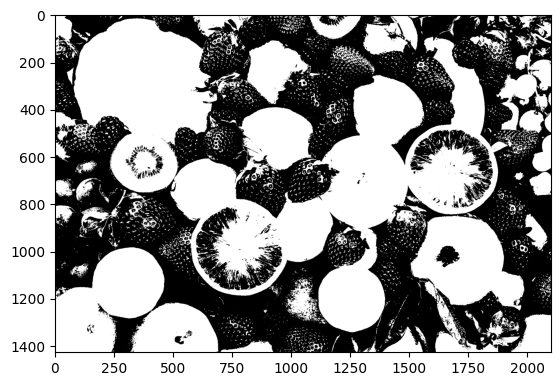

In [1]:
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
import matplotlib.pylab as plt
from skimage.filters.thresholding import threshold_otsu

data = Image.open('fruit.jpg').convert('L')
a = np.array(data)
thres = threshold_otsu(a)
b = a > thres
b = Image.fromarray(b)
plt.imshow(b)
plt.show()

2.2.2. Phương pháp Adaptive Thresholding

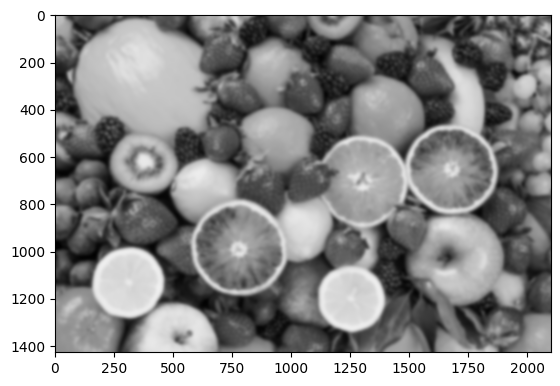

In [2]:
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
import matplotlib.pylab as plt
from skimage.filters.thresholding import threshold_local
data = Image.open('fruit.jpg').convert('L')
a = np.array(data)
b =  threshold_local(a, 39, offset=10)
b = Image.fromarray(b)
plt.imshow(b)
plt.show()

2.2. Phân vùng theo region

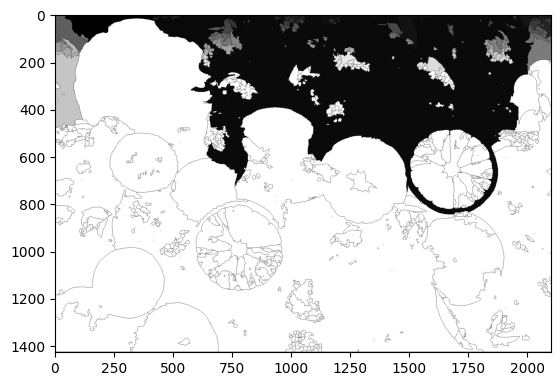

In [3]:
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from scipy.ndimage import label
import matplotlib.pylab as plt
from skimage.filters.thresholding import threshold_local

data = cv2.imread('fruit.jpg')
a = cv2.cvtColor(data, cv2.COLOR_BGR2GRAY)
thresh, b1 = cv2.threshold(a, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
b2 = cv2.erode(b1, None, iterations=2)
dist_trans = cv2.distanceTransform(b2, 2, 3)
thresh, dt = cv2.threshold(dist_trans, 1, 255, cv2.THRESH_BINARY)
labelled, ncc = label(dt)
labelled = labelled.astype(np.int32)
cv2.watershed(data, labelled)
b = Image.fromarray(labelled)

plt.imshow(b)
plt.show()

2.3. Biến đổi đối tượng trong ảnh

2.3.1. Sử dụng binary_dilation

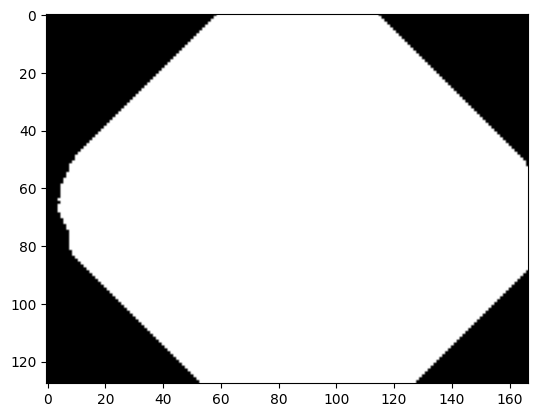

In [6]:
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
import matplotlib.pylab as plt
from skimage.filters import threshold_local

data = Image.open('image.png').convert('L')
b = nd.binary_dilation(data, iterations=50)
c = Image.fromarray(b)
c.show()
plt.imshow(c)
plt.show()

2.3.2. Sử dụng binary_opening

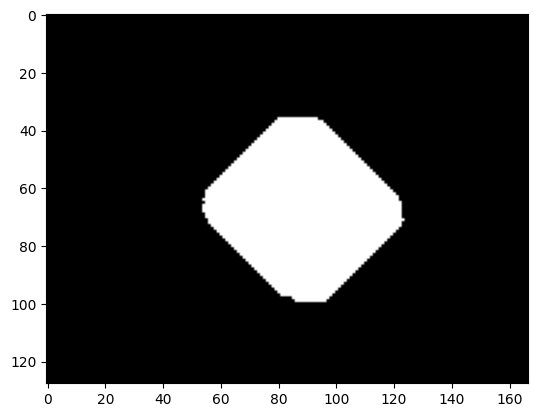

In [7]:
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
import matplotlib.pylab as plt
from skimage.filters import threshold_local

data = Image.open('image.png').convert('L')
s = [[0, 1, 0], [1, 1, 1], [0, 1, 0]]
b = nd.binary_opening(data, structure=s, iterations=25)
c = Image.fromarray(b)
c.show()
plt.imshow(c)
plt.show()

2.3.3. Sử dụng binary_erosion

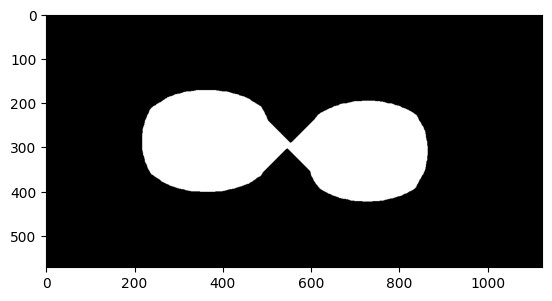

In [12]:
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from scipy.ndimage import label
import matplotlib.pylab as plt
from skimage.filters import threshold_local
data = Image.open('image.jpg').convert('L')
img = np.array(data)
binary = img > 128
s = np.array([[0, 1, 0], [1, 1, 1], [0, 1, 0]])
b = nd.binary_erosion(binary, structure=s, iterations=50)
c = Image.fromarray((b * 255).astype(np.uint8))
c.show()

plt.imshow(c, cmap='gray')
plt.show()

2.3.4. Sử dụng binary_closing

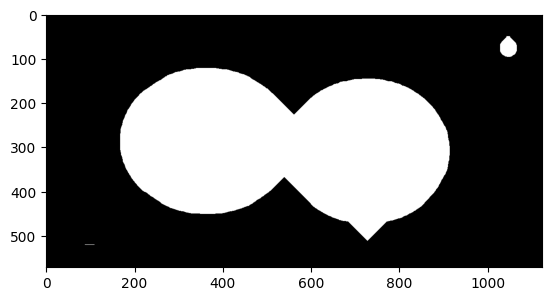

In [14]:
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from scipy.ndimage import label
import matplotlib.pylab as plt
from skimage.filters import threshold_local

data = Image.open('image.jpg').convert('L')
img = np.array(data)
binary = img > 128
s = np.array([[0, 1, 0], [1, 1, 1], [0, 1, 0]])
b = nd.binary_closing(binary, structure=s, iterations=50)
c = Image.fromarray((b * 255).astype(np.uint8))
c.show()
plt.imshow(c, cmap='gray')
plt.show()

3. BÀI TẬP

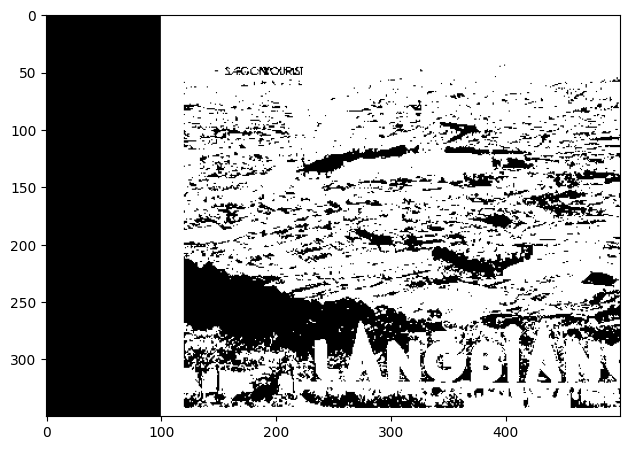

In [18]:
#1.py
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
import matplotlib.pylab as plt
from skimage.filters import threshold_otsu
data = iio.imread('exercise/dalat.jpg', mode='F') 
img = data[0:350, 0:500]
shifted = nd.shift(img, shift=(0, 100))

if shifted.max() > 1.0:
    norm = shifted / 255.0
else:
    norm = shifted
otsu_thresh = threshold_otsu(norm)
segmented = norm > otsu_thresh  
a = Image.fromarray((segmented * 255).astype(np.uint8))
a.save('lang_biang.jpg')
plt.imshow(a, cmap='gray')
plt.tight_layout()
plt.show()


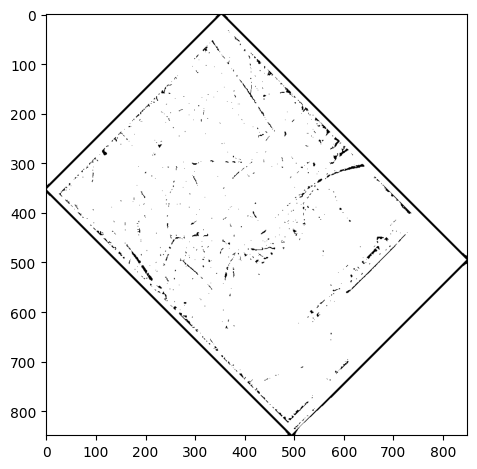

In [19]:
#2.py
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
import matplotlib.pylab as plt
from skimage.filters import threshold_local

data = iio.imread('exercise/dalat.jpg', mode='F') 
img = data[0:700, 500:1000]
rotate = nd.rotate(img, 45, reshape=True)

a = np.asarray(rotate)
b = threshold_local(a, block_size=39, offset=60)
binary = a > b
c = Image.fromarray((binary * 255).astype(np.uint8))
c.save('ho_xuan_huong.jpg')
plt.imshow(c, cmap='gray')
plt.tight_layout()
plt.show()

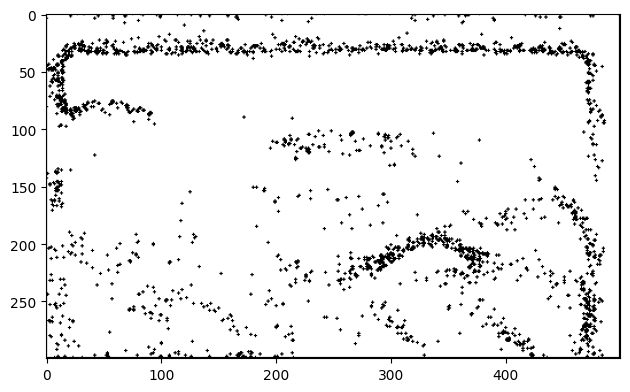

In [22]:
#3.py
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from scipy.ndimage import label
import matplotlib.pylab as plt
from skimage.filters import threshold_local

data = iio.imread('exercise/dalat.jpg', mode='F')
img = data[0:300, 1000:1500]
V, H = img.shape
M = np.indices((V, H))
d = 15
q = 2 * d * np.random.ranf(M.shape) - d
mp = (M + q).astype(int)
mp[0] = np.clip(mp[0], 0, V - 1)
mp[1] = np.clip(mp[1], 0, H - 1)
img = nd.map_coordinates(img, mp)
T = threshold_local(img, 35, offset=10)
binary = img > T
s = np.array([[0, 1, 0], [1, 1, 1], [0, 1, 0]])
b = nd.binary_closing(binary, structure=s, iterations=1)
c = Image.fromarray((b * 255).astype(np.uint8))
c.save('quang_truong_lam_vien.jpg')
plt.imshow(c, cmap='gray')
plt.tight_layout()
plt.show()

== geometric_transformation ==
0. Không chọn chức năng
1. Coordinate_mapping
2. Rotate
3. Scale
4. Shift
== segment ==
0. Không chọn chức năng
5. Adaptive_thresholding
6. Binary_dilation
7. Binary_erosion
8. Otsu


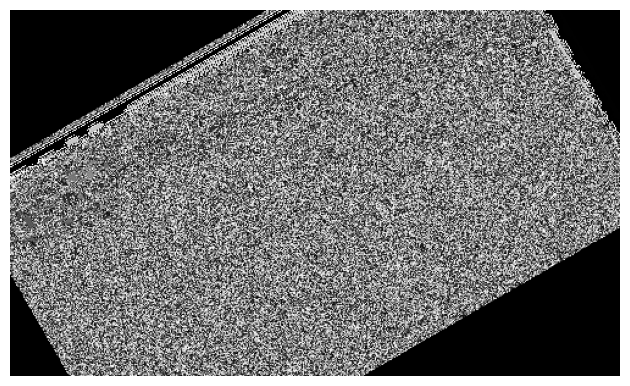

In [1]:
#4.py
import cv2
import numpy as np
from PIL import Image
import imageio.v2 as iio
import scipy.ndimage as nd
from skimage.filters import threshold_local, threshold_otsu
import matplotlib.pyplot as plt

img = iio.imread('exercise/dalat.jpg', mode='F')
img = img[0:300, 1000:1500]

print('== geometric_transformation ==')
print('0. Không chọn chức năng')
print('1. Coordinate_mapping')
print('2. Rotate')
print('3. Scale')
print('4. Shift')

print('== segment ==')
print('0. Không chọn chức năng')
print('5. Adaptive_thresholding')
print('6. Binary_dilation')
print('7. Binary_erosion')
print('8. Otsu')

geo_choice = input("Chọn chức năng (0-4): ")
seg_choice = input("Chọn chức năng (0, 5-8): ")

a = img.copy()

# ======= Geometric Transformation =======
if geo_choice == '1': 
    a = nd.map_coordinates(a, np.indices(a.shape) + 10)
elif geo_choice == '2':
    a = nd.rotate(a, angle=30, reshape=False)
elif geo_choice == '3':
    a = nd.zoom(a, zoom=1.2)
    h, w = img.shape
    a = a[:h, :w]
elif geo_choice == '4':
    a = nd.shift(a, shift=(30, 30))

# ======= Segment =======
if seg_choice == '5':
    T = threshold_local(a, block_size=35, offset=10)
    a = a > T
elif seg_choice == '6':
    a = a > 0.3
    a = nd.binary_dilation(a)
elif seg_choice == '7':
    a = a > 0.3
    a = nd.binary_erosion(a)
elif seg_choice == '8':
    thresh = threshold_otsu(a)
    a = a > thresh

output = (a * 255).astype(np.uint8)
b = Image.fromarray(output)
b.save('output_dalat.jpg')
plt.imshow(b, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()